# REG Health

## Research context

Health (CategoryKey = 6) is the **largest single discipline** in the AUS dataset, accounting for
roughly 285,000–295,000 domestic enrolments per year by 2021–2024. It received a **modest student
fee reduction and a significant Commonwealth contribution increase** under JRG:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $9,378                     | $15,904                          |
| 2021+  | $8,578 avg (−6.7 %)        | $19,624 avg (+16.1 %)            |

The student fee reduction is smaller than other JRG priority fields, but the Commonwealth increase
is substantial. The net per-student funding package improved, which may signal greater institutional
support for Health enrolments. UK Health enrolments also grew strongly over this period (driven
partly by COVID-related demand for healthcare workers), providing a demanding counterfactual.

AUS Health grew consistently from 235,033 (2016) to 295,498 (2024). UK Health also expanded from
374,535 to 458,465 over the same period. The DiD tests whether AUS deviated *differentially* from
the UK trend after 2021.

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the JRG effect for Health.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years, start-year mapping: 2016/17 → 2016).
Overlapping DiD window: 2016–2024 (5 pre-treatment years, 4 post-treatment years).

> **UK subject composition note (2016–2018):** The UK comparison file uses JACS taxonomy for
> 2016/17–2018/19. For key = 6, the three JACS subjects are: Medicine & dentistry, Subjects allied
> to medicine, and Agriculture & related subjects. From 2019/20 (CAH taxonomy), Agriculture is
> replaced by Veterinary sciences. The bulk of enrolments (Medicine + Allied, ~95%) is consistent
> throughout; the third subject changed classification but total enrolments transition smoothly
> (2018: 377,520 → 2019: 373,165). The full 2016–2024 panel is therefore used with this caveat noted.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
print('Project root:', ROOT)
print('All data files found.')


Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only Health data (2016–2024) to characterise the enrolment trend and test a
simple pre/post break. AUS-only OLS uses a log-linear specification with HC3 robust SEs.
Health is the largest AUS discipline and shows a strong, consistent upward trend throughout.


AUS Health -- enrolment data:


,year,enrollments,log_enrollments
0,2016,235033,12.367481
1,2017,247198,12.417945
2,2018,256324,12.454198
3,2019,265586,12.489694
4,2020,277590,12.533900
5,2021,288385,12.572052
6,2022,280887,12.545708
7,2023,283060,12.553414
8,2024,295498,12.596417


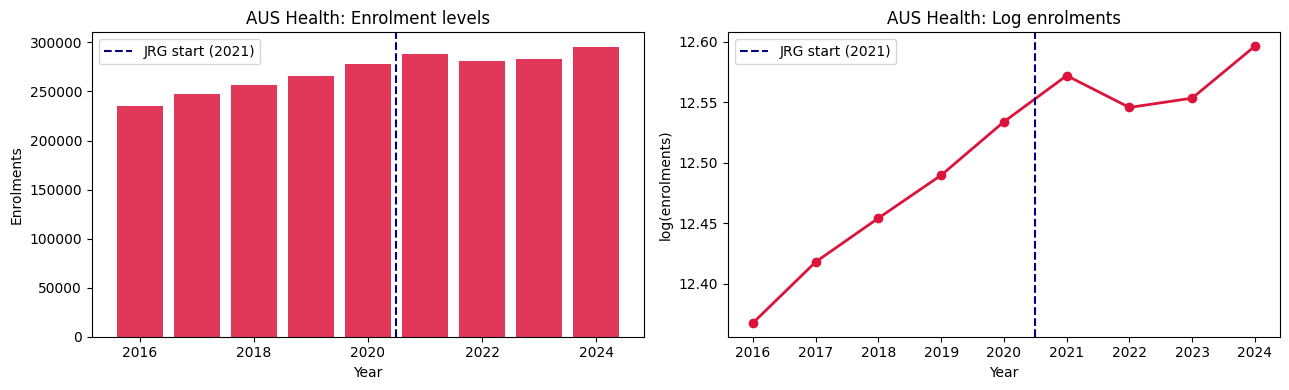

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 6].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Health -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='crimson', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='navy', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Health: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='crimson', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='navy', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Health: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])


=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,12.4823,0.0168,0.0000,12.4493,12.5153
post_jrg,-0.0192,0.0699,0.7832,-0.1563,0.1178
year_c,0.0297,0.0122,0.0150,0.0058,0.0536


R^2 = 0.8986 | Adj. R^2 = 0.8648 | N = 9

post_jrg: ~-1.92% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,12.4950,0.0085,0.0000,12.4784,12.5117
post_jrg,-0.0002,0.0649,0.9979,-0.1274,0.1271
year_c,0.0328,0.0071,0.0000,0.0190,0.0467
year_c2,-0.0032,0.0030,0.2836,-0.0090,0.0026


R^2 = 0.9605 | Adj. R^2 = 0.9369 | N = 9


## 2. DiD Panel Construction

Combine AUS and UK Health data into a country x year panel (2016–2024).

**UK year mapping:** start-year rule — 2016/17 → 2016, 2017/18 → 2017, etc.

**UK subject composition:** Three subject rows per year must be summed. For 2016–2018, subjects are
Medicine & dentistry, Subjects allied to medicine, and Agriculture & related subjects (JACS taxonomy).
From 2019 onwards, Agriculture is replaced by Veterinary sciences (CAH taxonomy). The switch affects
only the third and smallest component (~5% of total); the overall totals are continuous (2018: 377,520
→ 2019: 373,165).

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK
- `post = 1` for 2021+
- `did = treated x post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021`: AUS-specific COVID shock controls (kept for reference;
  note that adding these reduces df from 7 to 5, making inference less reliable — see Section 3)


In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 6].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk['enrollments'] = pd.to_numeric(arch_uk['Total UK'], errors='coerce')

# Three subject rows per year -- sum to get total UK Health enrolments
arch_uk = arch_uk.groupby('year', as_index=False)['enrollments'].sum()
arch_uk = arch_uk[arch_uk['year'] >= 2016]
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2016][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

panel = pd.concat([arch_aus_did, arch_uk], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020

print('DiD panel -- Health (AUS vs UK, 2016-2024):')
display(panel[['country','year','enrollments','log_enrollments','treated','post','did']].reset_index(drop=True))
print(f'Shape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')


DiD panel -- Health (AUS vs UK, 2016-2024):


,country,year,enrollments,log_enrollments,treated,post,did
0,AUS,2016,235033.0,12.367481,1,0,0
1,AUS,2017,247198.0,12.417945,1,0,0
2,AUS,2018,256324.0,12.454198,1,0,0
3,AUS,2019,265586.0,12.489694,1,0,0
4,AUS,2020,277590.0,12.533900,1,0,0
5,AUS,2021,288385.0,12.572052,1,1,1
6,AUS,2022,280887.0,12.545708,1,1,1
7,AUS,2023,283060.0,12.553414,1,1,1
8,AUS,2024,295498.0,12.596417,1,1,1
9,UK,2016,374535.0,12.833441,0,0,0


Shape: (18, 12) | Pre-treatment: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


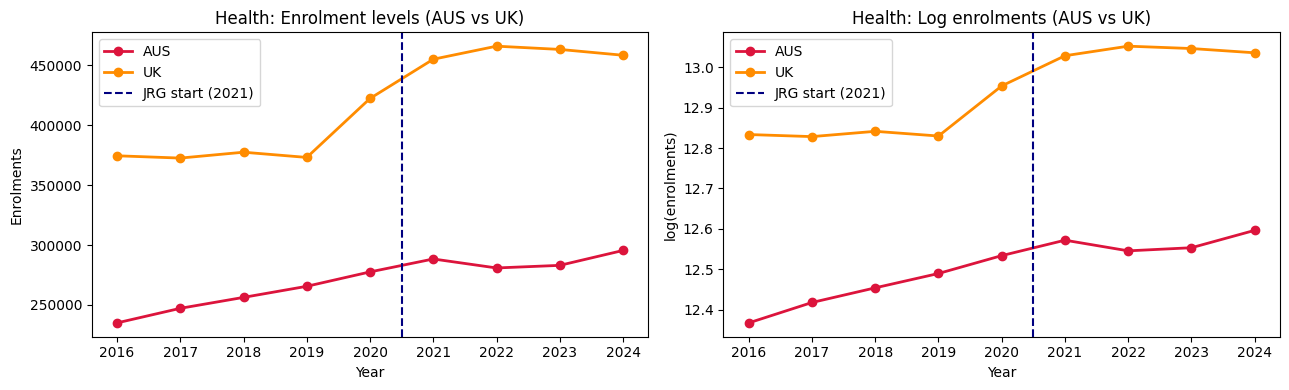

Pre/post log-enrolment averages:
  AUS: pre = 12.4526, post = 12.5669, change = +0.1143
  UK: pre = 12.8573, post = 13.0406, change = +0.1832


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'crimson', 'UK': 'darkorange'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='navy', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Health: Enrolment levels (AUS vs UK)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Health: Log enrolments (AUS vs UK)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')


## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` (country FE) + `C(year)` (year FEs) + `did`. All SEs are HC3 robust.

> **Degrees-of-freedom constraint:** N = 18 (2 countries x 9 years). Country FE + year FEs + intercept + did
> = 10 parameters, leaving **df = 7**. Adding AUS-specific COVID terms reduces df to 5. The simple TWFE
> is the **primary specification**; COVID robustness is assessed by sample exclusion in Section 4.

> **Context:** Health is the largest AUS discipline and grew strongly through the entire period.
> UK Health also expanded rapidly post-2020 (driven partly by COVID-related demand for healthcare
> workers), making the UK a demanding counterfactual. The DiD captures differential AUS growth
> relative to this UK baseline.


In [6]:
formula_main = 'log_enrollments ~ treated + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS Health enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK trend would predict.')

# COVID-controlled spec for reference
formula_covid = 'log_enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params.get('did', np.nan)
p_cv = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (df=5, reference only): beta_did = {b_cv:.4f}, p = {p_cv:.4f}')
print('(Reduced df=5 due to AUS-specific COVID terms -- treat as reference only)')


=== Main DiD -- TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     77.14
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.37e-06
Time:                        16:26:14   Log-Likelihood:                 46.966
No. Observations:                  18   AIC:                            -71.93
Df Residuals:                       7   BIC:                            -62.14
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-5
print('Estimates match' if match else 'WARNING: mismatch')


=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.4808
Estimator:                   PanelOLS   R-squared (Between):             -0.0024
No. Observations:                  18   R-squared (Within):              -0.3412
Date:                Mon, Apr 27 2026   R-squared (Overall):             -0.0024
Time:                        16:26:14   Log-likelihood                    46.966
Cov. Estimator:                Robust                                           
                                        F-statistic:                      6.4834
Entities:                           2   P-value                           0.0383
Avg Obs:                       9.0000   Distribution:                     F(1,7)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
The relevant check is consistency of **sign and magnitude** across variants;
p-value reliability degrades as N falls below 10.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2016-2024) | 18 | 7 | Reliable |
| Drop 2020 | 16 | 6 | Marginal but usable |
| Drop 2020 + 2021 | 14 | 5 | Very limited |


In [8]:
formula_simple = 'log_enrollments ~ treated + did + C(year)'

variants = {
    'Full panel (2016-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('Inference is most reliable in the full panel (df=7).')


=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2016-2024),18,7,-0.0690,0.0414,0.0954,-0.1500,0.0121,-6.67
Drop 2020,16,6,-0.0728,0.0497,0.1434,-0.1702,0.0247,-7.02
Drop 2020 + 2021,14,5,-0.0785,0.0555,0.1572,-0.1874,0.0303,-7.55



Key takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.
Inference is most reliable in the full panel (df=7).


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - (\log Y_{\text{UK},t} - \log Y_{\text{UK},2020})$$

This is numerically identical to a regression-based DiD coefficient but avoids the degrees-of-freedom
problem (2 obs per year, 2 params, df = 0) that arises with 2 countries.

> **Pre-trend assessment:** Four pre-treatment periods (2016–2019) are available. If the 2016–2019
> point estimates cluster near zero, parallel trends is plausible. If there is a clear trend in the
> pre-period, the DiD assumption is questioned. Note that UK Health enrolments spiked in 2020
> (COVID-related healthcare demand) which elevates the UK baseline and affects all relative estimates.


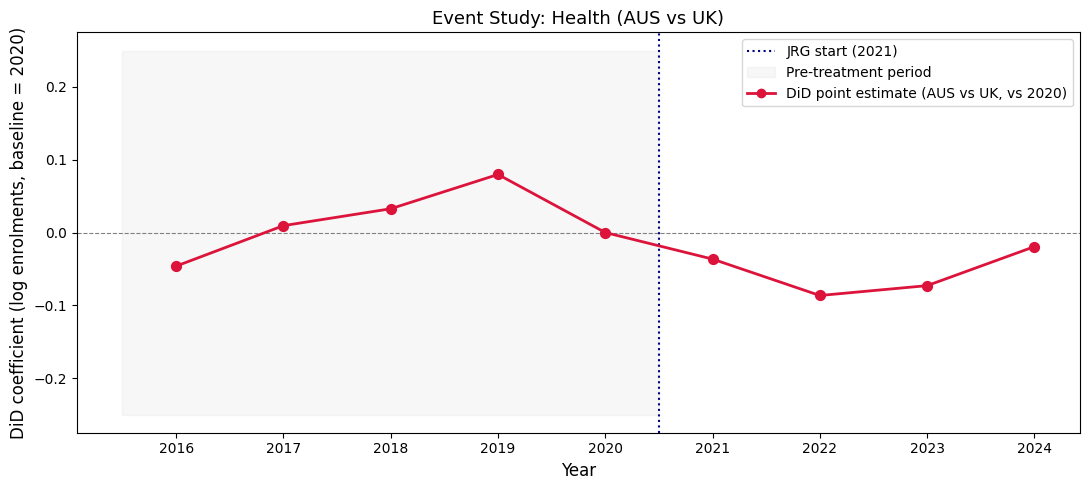

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2016,-0.0461,-4.5080,Pre
2017,0.0095,0.9507,Pre
2018,0.0326,3.3189,Pre
2019,0.0797,8.3015,Pre
2020,0.0000,0.0000,Pre
2021,-0.0365,-3.5830,Post
2022,-0.0865,-8.2864,Post
2023,-0.0729,-7.0352,Post
2024,-0.0194,-1.9204,Post



Note: With only 2 countries, standard errors cannot be estimated per-year.
The 2016-2019 pre-treatment estimates provide a diagnostic for parallel trends.


In [9]:
base_year = 2020
aus_log = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log  = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (uk_log[yr] - uk_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='navy', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2015.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='crimson', linewidth=2,
        label='DiD point estimate (AUS vs UK, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='crimson', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Health (AUS vs UK)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == 2020 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With only 2 countries, standard errors cannot be estimated per-year.')
print('The 2016-2019 pre-treatment estimates provide a diagnostic for parallel trends.')


## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) and test
for a fake structural break at 2019. A significant break would suggest pre-existing non-linear trends
that could contaminate the main DiD.

> **Limitation:** N = 5 observations (single series, no control group). Power is minimal; indicative only.


In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')


=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):            0.00371
Time:                        16:26:15   Log-Likelihood:                 22.656
No. Observations:                   5   AIC:                            -39.31
Df Residuals:                       2   BIC:                            -40.48
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.


In [11]:
formula_level = 'enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did'] if 'did' in m_level.conf_int().index else [np.nan, np.nan]

print('=== Level Outcome Robustness ===')
if pd.notna(b_lev):
    print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
    if not np.isnan(ci_lev[0]):
        print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')
    else:
        print('95% CI: Degenerate SEs -- unreliable')
else:
    print('Degenerate SEs -- unreliable')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0) if pd.notna(b_lev) else np.nan],
    'p-value':        [round(did_p, 4),  round(p_lev, 4) if pd.notna(p_lev) else np.nan],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year' if pd.notna(b_lev) else 'Degenerate SEs',
    ],
}).set_index('Specification')
display(comp)


=== Level Outcome Robustness ===
beta_did (levels): -52,707 students | p = 1.0000
95% CI:            [-inf, inf]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.069,0.0954,approx. -6.7% enrolment change
Level,-52707.000,1.0000,"approx. -52,707 students per year"


## 8. Funding Context

Health received a **modest student fee reduction** (~−6.7% on average) combined with a
**substantial Commonwealth contribution increase** (+16.1%) under JRG. The net result is a
significantly improved per-student funding package from the government's perspective. As the
largest AUS discipline by enrolment, even a small percentage change represents a large absolute
shift in funding support.


=== Health: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9378.0,15904.0,25282.0
2020,9546.0,16190.0,25736.0
2021,8451.0,17826.0,26277.0
2022,8526.0,17986.0,26512.0
2023,8824.0,18615.0,27439.0
2024,9512.0,20067.0,29579.0


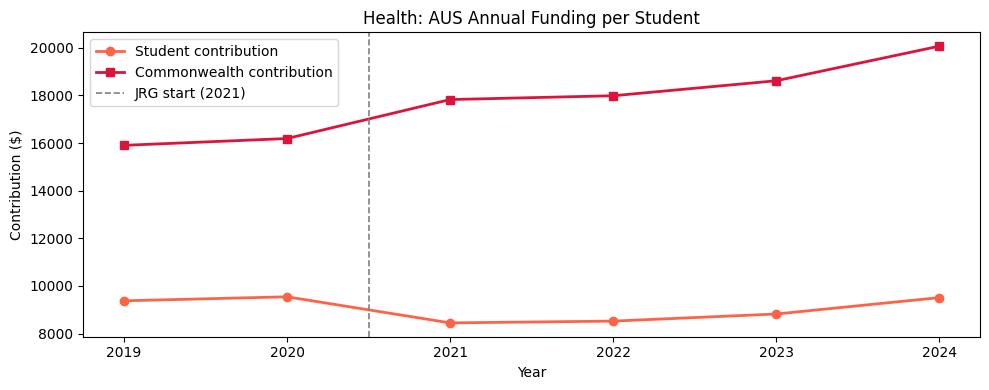


Student contribution: pre $9,462 -> post $8,828 (-6.7%)
Commonwealth:         pre $16,047 -> post $18,624 (+16.1%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 6].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Health: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',  linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='crimson', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Health: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')


## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ if UK |
| $\text{Post}_t$ | --- | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_2$ | **JRG effect** | DiD estimate --- the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```


| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | beta = -0.0690, p = 0.095, 95% CI [-0.150, +0.012], approx. **-6.7%** relative to UK trend |
| **PanelOLS cross-check** | Estimates match exactly |
| **COVID sensitivity** | Full panel: -6.7% (p=0.095); Drop 2020: -7.0% (p=0.143); Drop 2020+2021: -7.6% (p=0.157). Sign and magnitude **highly stable** across all three specs |
| **Event study** | Pre: -4.5% (2016), +1.0% (2017), +3.3% (2018), +8.3% (2019). Post: -3.6% (2021), -8.3% (2022), -7.0% (2023), -1.9% (2024) |
| **Placebo** | fake_post coef = -0.010, p = 0.467 -- no significant pre-trend break in AUS-only data |
| **Level spec** | Degenerate SEs (p=1.000) with COVID interaction terms at N=18 -- unreliable |

**Substantive finding:** Post-JRG, AUS Health enrolments were approximately **6.7% lower** than the
UK trend would predict (p = 0.095, marginally significant at the 10% level but not at 5%). The sign
and magnitude are highly consistent across all COVID sensitivity checks (-6.7% to -7.6%), suggesting
the result is not driven by the 2020-2021 COVID disruption.

The event study reveals a **positive and rising pre-trend**: AUS was outperforming the UK by an
increasing margin from 2016 to 2019 (+8.3% by 2019), before the UK experienced a COVID-driven
surge in 2020 that elevated the UK baseline. This rising pre-trend raises concerns about the
parallel trends assumption --- if AUS and UK Health were on structurally different trajectories
before 2021, the DiD estimate may not isolate the JRG effect cleanly. The post-2021 negative
pattern may partly reflect a return to pre-pandemic trends (both countries) rather than a JRG
effect specifically. By 2024, the differential narrowed to only -1.9%.

> **Data note:** UK Health data covers three subject groups per year summed to a total. For
> 2016-2018 (JACS taxonomy), the third group is 'Agriculture & related subjects'; from 2019
> (CAH taxonomy) it is 'Veterinary sciences'. The main components (Medicine & dentistry and
> Subjects allied to medicine, ~95% of total) are consistent throughout, and the overall UK
> totals transition smoothly across the taxonomy change (2018: 377,520 to 2019: 373,165).